# Name : Muhammad Danish Zaheer Awan
# REG id : 25280092
## Task 3 - Domain Generalization

## Imports and project setup

In [1]:
# Import standard utilities for cleanup, paths, tables, plotting, and PyTorch.
# Locate the repository root so imports work from either notebook location.

import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

In [2]:
working_directory = Path.cwd().resolve()
project_root = next(
    (path for path in (working_directory, *working_directory.parents)
     if (path / 'task3').is_dir() and (path / 'Data').is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError('Run this notebook from inside the PA_1 project.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
# Import the Task 3 source-only PACS protocol and YAML configuration helpers.
# These functions reuse Task 2 data while deliberately avoiding the Sketch folder.

from shared_task_2and3.pacs_protocol import (
    build_task3_source_datasets,
    prepare_task3_source_protocol,
)
from task3.configs.config_loader import (
    create_output_directories,
    get_output_paths,
    load_config,
)

In [4]:
# Import training and source-only diagnostic functions for the three methods.
# All functions in this cell operate without constructing a target dataset.

from task2.evaluation.metrics import save_json
from task3.evaluation.domain_metrics import evaluate_source_model
from task3.evaluation.sharpness import (
    calculate_local_sharpness,
    create_fixed_validation_batch,
)
from task3.evaluation.source_domain_separability import (
    evaluate_source_domain_separability,
)
from task3.training.train import (
    select_training_device,
    set_random_seed,
    train_or_load_task3_method,
)

In [5]:
# Import the lock and final Sketch evaluator without executing target access.
# Sketch images are constructed only when the later guarded function is called.

from task3.evaluation.evaluate_sketch import (
    create_experiment_lock,
    run_final_sketch_evaluation,
)

## Runtime and main configurations

In [6]:
# Define reproducible random generators and automatically prefer the CUDA GPU.
# The same seed is restored before each Task 3 model is initialized.

def configure_runtime(seed=6304):
    set_random_seed(seed)
    return select_training_device()

In [7]:
# Initialize the runtime and display the exact PyTorch compute environment.
# Training and feature extraction use CUDA while sklearn diagnostics use CPU.

DEVICE = configure_runtime()
print(f'Project root: {project_root}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Project root: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1
PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [8]:
# Define one helper that loads ERM, DAN-DG, and SAM main configurations.
# ERM is marked load-only and points directly to the Task 2 checkpoint.

def load_main_configurations():
    return {
        method_name: load_config(method_name)
        for method_name in ('erm', 'dan_dg', 'sam')
    }

In [9]:
# Load the main configurations and create Task 3 cache and result directories.
# Display method settings before loading data or checkpoints.

MAIN_CONFIGURATIONS = load_main_configurations()
OUTPUT_PATHS = create_output_directories(MAIN_CONFIGURATIONS['erm'])
display(pd.DataFrame([config['method'] for config in MAIN_CONFIGURATIONS.values()]))

,name,run_name,trainable,reuse_task2_source_only,mmd_weight,kernel_bandwidth_multipliers,rho,adaptive
0,erm,erm,False,True,NaN,NaN,NaN,NaN
1,dan_dg,dan_dg,True,NaN,1.0,"[0.5, 1.0, 2.0]",NaN,NaN
2,sam,sam,True,NaN,NaN,NaN,0.05,False


## Reuse the source-only PACS protocol

In [10]:
# Define source-protocol loading from the PACS data and split prepared by Task 2.
# The implementation validates Photo, Art Painting, and Cartoon without scanning Sketch.

def prepare_task3_sources(configuration):
    paths = get_output_paths(configuration)
    return prepare_task3_source_protocol(
        dataset_directory=paths['dataset_directory'],
        split_file=paths['split_file'],
    )

In [11]:
# Load only the existing source image root and fixed Task 2 split information.
# Run Task 2 data preparation first if either dependency does not exist.

PACS_SOURCE_ROOT, PACS_PROTOCOL = prepare_task3_sources(
    MAIN_CONFIGURATIONS['erm']
)

PACS source root: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\Data\pacs
Reused PACS protocol: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\shared_task_2and3\splits\pacs_sketch_seed6304.json


In [12]:
# Define the source training and validation datasets with Task 2 transforms.
# The returned dictionary has no target, adaptation, or Sketch dataset key.

def create_task3_datasets(image_root, protocol, configuration):
    transform_settings = configuration['transforms']
    return build_task3_source_datasets(
        image_root,
        protocol,
        resize_size=transform_settings['resize_size'],
        crop_size=transform_settings['crop_size'],
    )

In [13]:
# Construct source-only datasets and assert the strict two-key boundary.
# This prevents a target dataset from reaching Task 3 training code.

TASK3_DATASETS = create_task3_datasets(
    PACS_SOURCE_ROOT,
    PACS_PROTOCOL,
    MAIN_CONFIGURATIONS['erm'],
)
assert set(TASK3_DATASETS) == {'source_train', 'source_validation'}

In [14]:
# Define a compact table for the reused source training and validation splits.
# The counts should match the corresponding Task 2 source-domain counts exactly.

def create_source_size_table(datasets):
    rows = []
    for split_name in ('source_train', 'source_validation'):
        for domain, dataset in datasets[split_name].items():
            rows.append({
                'domain': domain,
                'split': split_name.replace('source_', ''),
                'number_of_examples': len(dataset),
            })
    return pd.DataFrame(rows)

In [15]:
# Display the source-only dataset sizes before loading the shared ERM baseline.
# No target count or target sample is inspected anywhere in this stage.

display(create_source_size_table(TASK3_DATASETS))

,domain,split,number_of_examples
0,photo,train,1336
1,art_painting,train,1638
2,cartoon,train,1875
3,photo,validation,334
4,art_painting,validation,410
5,cartoon,validation,469


## Common training and memory helper

In [16]:
# Define one wrapper for load-only ERM and source-only DAN-DG or SAM training.
# Release model tensors afterward so sequential experiments fit on the GPU.

def run_and_release(configuration, datasets, force_retrain=False):
    result = train_or_load_task3_method(
        configuration,
        datasets,
        device=DEVICE,
        force_retrain=force_retrain,
    )
    compact_result = {
        'checkpoint_file': result['checkpoint_file'],
        'history_file': result['history_file'],
        'history': result['history'],
        'selected_epoch': result['checkpoint']['epoch'],
        'selection_value': result['checkpoint']['selection_value'],
        'source_validation': result['checkpoint']['source_validation'],
        'reused_from_task2': result['reused_from_task2'],
    }
    result['model'].to('cpu')
    del result
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return compact_result

In [17]:
# Choose whether completed DAN-DG and SAM checkpoints should be overwritten.
# This flag never retrains ERM because its Task 2 checkpoint is always load-only.
FORCE_RETRAIN = False
TRAINING_RESULTS = {}

## 1. Shared ERM baseline

In [18]:
# Load the unchanged source-selected Task 2 Source-only checkpoint as ERM.
# The loader verifies its method and source-validation selection criterion.

TRAINING_RESULTS['erm'] = run_and_release(
    MAIN_CONFIGURATIONS['erm'],
    TASK3_DATASETS,
    force_retrain=False,
)
print(TRAINING_RESULTS['erm']['checkpoint_file'])
print('Reused from Task 2:', TRAINING_RESULTS['erm']['reused_from_task2'])

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded unchanged Task 2 ERM checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\checkpoints\source_only_best.pt
C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task2\results\checkpoints\source_only_best.pt
Reused from Task 2: True


## 2. DAN-DG

In [19]:
# Train DAN-DG with the exact Task 2 MMD over all three source pairs.
# Classification and alignment use only Photo, Art Painting, and Cartoon.

TRAINING_RESULTS['dan_dg'] = run_and_release(
    MAIN_CONFIGURATIONS['dan_dg'],
    TASK3_DATASETS,
    force_retrain=FORCE_RETRAIN,
)
display(TRAINING_RESULTS['dan_dg']['history'].tail())

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded Task 3 checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task3\results\checkpoints\dan_dg_best.pt


,epoch,total_loss,classification_loss,mmd_loss,photo_validation_accuracy,photo_validation_macro_f1,art_painting_validation_accuracy,art_painting_validation_macro_f1,cartoon_validation_accuracy,cartoon_validation_macro_f1,mean_source_validation_accuracy,mean_source_validation_macro_f1,worst_source_validation_accuracy,worst_source_validation_macro_f1
2,3,2.098140,1.939188,0.158952,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.05067,0.172708,0.042078
3,4,1.938567,1.938003,0.000563,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.05067,0.172708,0.042078
4,5,1.936551,1.935724,0.000827,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.05067,0.172708,0.042078
5,6,1.935298,1.934833,0.000465,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.05067,0.172708,0.042078
6,7,1.933051,1.932795,0.000256,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.05067,0.172708,0.042078


## 3. SAM

In [20]:
# Train standard non-adaptive SAM with radius 0.05 and wrapped AdamW.
# Both ascent and descent passes reuse the same balanced source images.

TRAINING_RESULTS['sam'] = run_and_release(
    MAIN_CONFIGURATIONS['sam'],
    TASK3_DATASETS,
    force_retrain=FORCE_RETRAIN,
)
display(TRAINING_RESULTS['sam']['history'].tail())

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded Task 3 checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task3\results\checkpoints\sam_best.pt


,epoch,total_loss,classification_loss,mmd_loss,sam_perturbed_loss,gradient_norm,photo_validation_accuracy,photo_validation_macro_f1,art_painting_validation_accuracy,art_painting_validation_macro_f1,cartoon_validation_accuracy,cartoon_validation_macro_f1,mean_source_validation_accuracy,mean_source_validation_macro_f1,worst_source_validation_accuracy,worst_source_validation_macro_f1
8,9,0.140901,0.030220,0.0,0.140901,1.146135,0.970060,0.965210,0.902439,0.898770,0.957356,0.962132,0.943285,0.942037,0.902439,0.898770
9,10,0.120745,0.023903,0.0,0.120745,0.939699,0.973054,0.967286,0.924390,0.923740,0.959488,0.964325,0.952311,0.951783,0.924390,0.923740
10,11,0.122480,0.021349,0.0,0.122480,0.946248,0.982036,0.978046,0.917073,0.912213,0.961620,0.966578,0.953577,0.952279,0.917073,0.912213
11,12,0.113866,0.019800,0.0,0.113866,0.875940,0.976048,0.972131,0.895122,0.894628,0.953092,0.956591,0.941421,0.941117,0.895122,0.894628
12,13,0.127081,0.023174,0.0,0.127081,0.991818,0.976048,0.970650,0.919512,0.920252,0.957356,0.962557,0.950972,0.951153,0.919512,0.920252


## 4. Source-only training evidence

In [21]:
# Create a 2-by-3 grid so ERM, DAN-DG, and SAM have separate readable curves.
# Show each training objective above its source-validation accuracy and macro-F1.

from matplotlib.ticker import PercentFormatter

def plot_training_curves(training_results, output_file):
    method_specifications = [
        (
            'erm',
            'ERM',
            [('classification_loss', 'Classification loss', 'tab:blue', 'o', '-')],
        ),
        (
            'dan_dg',
            'DAN-DG',
            [
                ('classification_loss', 'Classification loss', 'tab:blue', 'o', '-'),
                ('mmd_loss', 'Pairwise source MMD', 'tab:orange', 's', '--'),
            ],
        ),
        (
            'sam',
            'SAM',
            [
                ('classification_loss', 'Original-batch loss', 'tab:blue', 'o', '-'),
                ('sam_perturbed_loss', 'Perturbed-weight loss', 'tab:orange', 's', '--'),
            ],
        ),
    ]
    figure, axes = plt.subplots(
        2,
        3,
        figsize=(15, 8),
        sharex='col',
        squeeze=False,
    )

    for column_index, (result_name, display_name, loss_metrics) in enumerate(
        method_specifications
    ):
        result = training_results[result_name]
        history = result['history']
        selected_epoch = result['selected_epoch']
        loss_axis = axes[0, column_index]
        metric_axis = axes[1, column_index]

        for metric_name, label, color, marker, line_style in loss_metrics:
            loss_axis.plot(
                history['epoch'],
                history[metric_name],
                marker=marker,
                linestyle=line_style,
                linewidth=2,
                label=label,
                color=color,
            )
        loss_axis.axvline(
            selected_epoch,
            color='black',
            linestyle=':',
            linewidth=1.5,
            label='Selected checkpoint',
        )
        loss_axis.set_title(f'{display_name}: training objectives')
        loss_axis.set_ylabel('Loss (log scale)')
        loss_axis.set_yscale('log')
        loss_axis.grid(alpha=0.3)
        loss_axis.legend(fontsize=8)

        metric_axis.plot(
            history['epoch'],
            history['mean_source_validation_accuracy'],
            marker='o',
            linewidth=2,
            label='Mean accuracy',
            color='tab:green',
        )
        metric_axis.plot(
            history['epoch'],
            history['mean_source_validation_macro_f1'],
            marker='s',
            linestyle='--',
            linewidth=2,
            label='Mean macro-F1',
            color='tab:purple',
        )
        metric_axis.axvline(
            selected_epoch,
            color='black',
            linestyle=':',
            linewidth=1.5,
            label='Selected checkpoint',
        )
        metric_axis.set_title(f'{display_name}: source validation')
        metric_axis.set_xlabel('Epoch')
        metric_axis.set_ylabel('Validation score')
        metric_axis.set_ylim(0.0, 1.0)
        metric_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
        metric_axis.grid(alpha=0.3)
        metric_axis.legend(fontsize=8)

    figure.suptitle(
        'Task 3 Training and Source-Validation Behaviour',
        fontsize=15,
    )
    figure.tight_layout(rect=[0, 0, 1, 0.96])
    figure.savefig(output_file, dpi=300, bbox_inches='tight')
    return figure

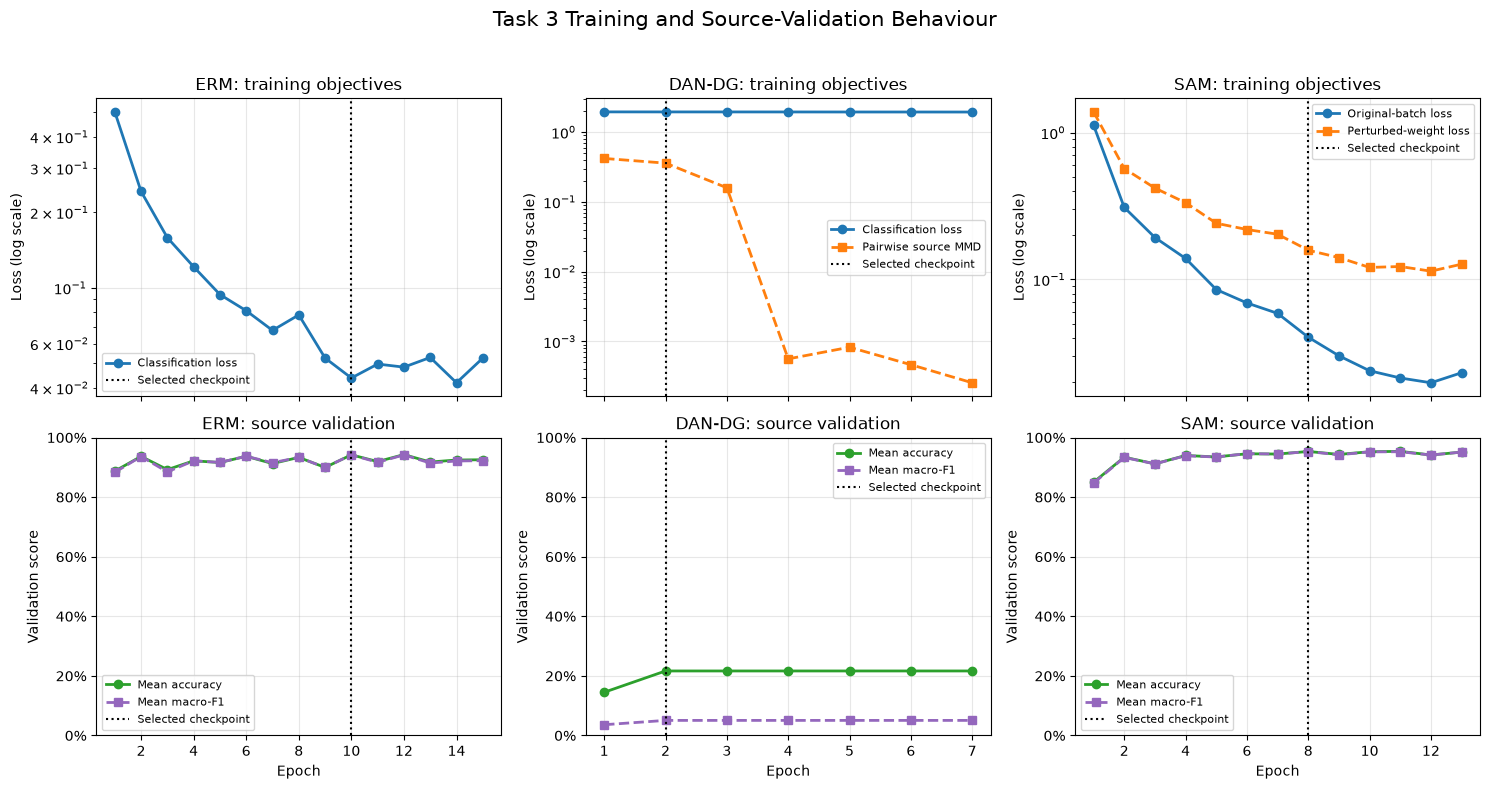

Saved: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task3\results\figures\main_training_curves.png


In [22]:
# Plot each method separately before any target evaluation is possible.
# Save classification, method-specific losses, and source-validation evidence.

TRAINING_CURVE_FILE = OUTPUT_PATHS['figures_directory'] / 'main_training_curves.png'
TRAINING_CURVE_FIGURE = plot_training_curves(
    TRAINING_RESULTS,
    TRAINING_CURVE_FILE,
)
plt.show()
print(f'Saved: {TRAINING_CURVE_FILE}')

In [23]:
# Define a source-selection table for reused ERM and both trained methods.
# Every selected value is mean macro-F1 over the same three source validations.

def create_selection_table(training_results):
    return pd.DataFrame([
        {
            'result_name': result_name,
            'selected_epoch': result['selected_epoch'],
            'mean_source_validation_macro_f1': result['selection_value'],
            'reused_from_task2': result['reused_from_task2'],
            'checkpoint_file': str(result['checkpoint_file']),
        }
        for result_name, result in training_results.items()
    ])

In [24]:
# Display all source-based selections without loading or inspecting Sketch.
# Confirm ERM is marked as reused while DAN-DG and SAM are Task 3 runs.

display(create_selection_table(TRAINING_RESULTS))

,result_name,selected_epoch,mean_source_validation_macro_f1,reused_from_task2,checkpoint_file
0,erm,10,0.941818,True,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...
1,dan_dg,2,0.050670,False,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...
2,sam,8,0.952813,False,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...


## Source-domain separability and common sharpness

In [25]:
# Define source-only diagnostics for one fixed model and common validation batch.
# The model is released after computing source metrics, separability, and sharpness.

def evaluate_source_diagnostics(configuration, datasets, fixed_batch):
    result = evaluate_source_model(configuration, datasets, DEVICE)
    diagnostics = configuration['diagnostics']
    separability = evaluate_source_domain_separability(
        result['model'],
        result['validation_loaders'],
        DEVICE,
        seed=configuration['seed'],
        training_ratio=diagnostics['diagnostic_train_ratio'],
        logistic_regression_c=diagnostics['logistic_regression_c'],
    )
    sharpness = calculate_local_sharpness(
        result['model'],
        fixed_batch,
        DEVICE,
        radius=diagnostics['sharpness_radius'],
    )
    source_metrics = result['metrics']
    result['model'].to('cpu')
    del result
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return {
        'source_metrics': source_metrics,
        'source_domain_separability': separability,
        'sharpness': sharpness,
    }

In [26]:
# Materialize exactly 32 fixed validation examples from each source domain.
# Reuse this identical 96-image tensor batch for every model's sharpness proxy.

FIXED_SHARPNESS_BATCH, FIXED_SHARPNESS_INDICES = create_fixed_validation_batch(
    TASK3_DATASETS['source_validation'],
    examples_per_domain=32,
    seed=6304,
)
save_json(
    FIXED_SHARPNESS_INDICES,
    OUTPUT_PATHS['metrics_directory'] / 'source_sharpness_indices.json',
)

In [27]:
# Compute the two required diagnostics for ERM, DAN-DG, and SAM using sources only.
# Save these measurements before the experiment lock and target-label evaluation.

SOURCE_DIAGNOSTICS = {
    result_name: evaluate_source_diagnostics(
        configuration,
        TASK3_DATASETS,
        FIXED_SHARPNESS_BATCH,
    )
    for result_name, configuration in MAIN_CONFIGURATIONS.items()
}
save_json(
    SOURCE_DIAGNOSTICS,
    OUTPUT_PATHS['metrics_directory'] / 'source_only_diagnostics.json',
)

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103


In [28]:
# Define a compact table for mean/worst source metrics and both diagnostics.
# This table can be interpreted safely before any Sketch images are loaded.

def create_source_diagnostic_table(source_diagnostics):
    return pd.DataFrame([
        {
            'result_name': result_name,
            'mean_source_accuracy': result['source_metrics']['mean_accuracy'],
            'mean_source_macro_f1': result['source_metrics']['mean_macro_f1'],
            'worst_source_accuracy': result['source_metrics']['worst_accuracy'],
            'worst_source_macro_f1': result['source_metrics']['worst_macro_f1'],
            'source_domain_separability': result['source_domain_separability']['accuracy'],
            'sharpness_increase': result['sharpness']['sharpness_increase'],
        }
        for result_name, result in source_diagnostics.items()
    ])

In [29]:
# Display source-only evidence and compare separability with its 33.3% chance level.
# Do not infer final Sketch performance from either diagnostic alone.

display(create_source_diagnostic_table(SOURCE_DIAGNOSTICS))

,result_name,mean_source_accuracy,mean_source_macro_f1,worst_source_accuracy,worst_source_macro_f1,source_domain_separability,sharpness_increase
0,erm,0.941869,0.941818,0.919512,0.916183,0.853821,0.375323
1,dan_dg,0.216568,0.050670,0.172708,0.042078,0.448505,0.006056
2,sam,0.953143,0.952813,0.934146,0.934684,0.853821,0.121355


## 5. Controlled SAM radius study

In [30]:
# Record student-written expectations before any controlled-study target results.
# Replace every TODO without using Task 2 Sketch results to revise Task 3 choices.

HYPOTHESES = {
    'main_methods': 'I expect ERM to remain a strong source baseline, while DAN-DG may improve domain invariance by aligning the three source domains but can also lose class information if alignment becomes too strong. SAM is expected to find a flatter solution and generalize better while preserving source classification.',
    'sam_radius': 'I expect a moderate SAM radius to give the best trade-off between source performance and flatness. A very small radius may behave close to ERM, while a large radius may make training difficult and reduce source and Sketch performance.',
    'task2_vs_task3_dan': 'I expect Task 2 DAN to have an advantage because it directly uses unlabeled Sketch examples for alignment. Task 3 DAN-DG only aligns the available source domains, so it may preserve source performance better but cannot directly correct the shift towards Sketch. However, target access alone may not help if the alignment becomes too strong.',
}
save_json(HYPOTHESES, OUTPUT_PATHS['metrics_directory'] / 'task3_hypotheses.json')
display(HYPOTHESES)

{'main_methods': 'I expect ERM to remain a strong source baseline, while DAN-DG may improve domain invariance by aligning the three source domains but can also lose class information if alignment becomes too strong. SAM is expected to find a flatter solution and generalize better while preserving source classification.',
 'sam_radius': 'I expect a moderate SAM radius to give the best trade-off between source performance and flatness. A very small radius may behave close to ERM, while a large radius may make training difficult and reduce source and Sketch performance.',
 'task2_vs_task3_dan': 'I expect Task 2 DAN to have an advantage because it directly uses unlabeled Sketch examples for alignment. Task 3 DAN-DG only aligns the available source domains, so it may preserve source performance better but cannot directly correct the shift towards Sketch. However, target access alone may not help if the alignment becomes too strong.'}

In [31]:
# Define the two extra SAM radii around the fixed main radius of 0.05.
# Unique run names prevent controlled checkpoints from replacing main SAM.

def build_sam_design_configurations():
    return {
        'sam_rho_0p01': load_config('sam', overrides={
            'method': {'run_name': 'sam_rho_0p01', 'rho': 0.01}
        }),
        'sam_rho_0p1': load_config('sam', overrides={
            'method': {'run_name': 'sam_rho_0p1', 'rho': 0.1}
        }),
    }

In [32]:
# Create and display the two additional fixed SAM configurations.
# The main SAM run supplies rho 0.05 without duplicate training.

DESIGN_CONFIGURATIONS = build_sam_design_configurations()
display(pd.DataFrame([
    {'result_name': name, 'rho': config['method']['rho']}
    for name, config in DESIGN_CONFIGURATIONS.items()
]))

,result_name,rho
0,sam_rho_0p01,0.01
1,sam_rho_0p1,0.10


In [33]:
# Define sequential source-only training for the extra SAM radius settings.
# Every non-radius setting remains identical to the main SAM experiment.

def train_sam_design_study(configurations, datasets, force_retrain=False):
    return {
        result_name: run_and_release(
            configuration,
            datasets,
            force_retrain=force_retrain,
        )
        for result_name, configuration in configurations.items()
    }

In [34]:
# Train or load both extra SAM runs and show their source-only selections.
# Complete both checkpoints before creating the experiment lock.

DESIGN_TRAINING_RESULTS = train_sam_design_study(
    DESIGN_CONFIGURATIONS,
    TASK3_DATASETS,
    force_retrain=FORCE_RETRAIN,
)
display(create_selection_table(DESIGN_TRAINING_RESULTS))

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded Task 3 checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task3\results\checkpoints\sam_rho_0p01_best.pt
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Loaded Task 3 checkpoint: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task3\results\checkpoints\sam_rho_0p1_best.pt


,result_name,selected_epoch,mean_source_validation_macro_f1,reused_from_task2,checkpoint_file
0,sam_rho_0p01,6,0.946942,False,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...
1,sam_rho_0p1,22,0.934466,False,C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\...


## Lock all decisions before loading Sketch

In [35]:
# Combine main and controlled configurations for one immutable experiment lock.
# The lock covers the reused ERM and every newly trained Task 3 checkpoint.

ALL_CONFIGURATIONS = {**MAIN_CONFIGURATIONS, **DESIGN_CONFIGURATIONS}
LOCK_FILE = OUTPUT_PATHS['metrics_directory'] / 'task3_experiment_lock.json'
print('Runs to lock:', list(ALL_CONFIGURATIONS))

Runs to lock: ['erm', 'dan_dg', 'sam', 'sam_rho_0p01', 'sam_rho_0p1']


In [36]:
# Hash the hypotheses, configurations, and checkpoints before target access.
# Incomplete hypotheses or any later change prevents final evaluation.

EXPERIMENT_LOCK = create_experiment_lock(ALL_CONFIGURATIONS, LOCK_FILE)
display(pd.DataFrame(EXPERIMENT_LOCK['runs']).T[[
    'method', 'run_name', 'checkpoint_sha256', 'configuration_sha256'
]])

Locked Task 3 decisions: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task3\results\metrics\task3_experiment_lock.json


,method,run_name,checkpoint_sha256,configuration_sha256
erm,erm,erm,64f089863fc171878a0a22fafc59a56514b1c25d2fbd7f...,45eac10685fddc4cd4323fc21ca9fe1cd826b47ece94c9...
dan_dg,dan_dg,dan_dg,ff9fde7b1f5b6340daa72e055d35dca10c7ff7f62c70d7...,109644a5519ece71c38bcaf7e600f7ba524977d35e8ec7...
sam,sam,sam,f45479f9fc438bf95d3527a11aa5310962779725a3ff28...,624dd329a31d1ba8b5dc4b1db4e0047b94c258fdadfc1d...
sam_rho_0p01,sam,sam_rho_0p01,6656cab5f1d22e67d2dd63968fe299803a1f458775dcda...,97bdfb7a3583ac4974dc4e9cbb255522a0136365f19bc4...
sam_rho_0p1,sam,sam_rho_0p1,b5ca8808c7a048b3625cdf0e0cf1d60ded0fd1b2bb4867...,80d48119abb466e6a5d9b57e1491a6ec265875315cf8bd...


## Final Sketch evaluation

In [37]:
# Keep Sketch access disabled until every preceding experiment decision is locked.
# Change this value to True only when ready for final target analysis.

UNLOCK_SKETCH = True
print('Final Sketch evaluation unlocked:', UNLOCK_SKETCH)

Final Sketch evaluation unlocked: True


In [38]:
# Run the protected evaluator only after the explicit final unlock decision.
# It saves aggregate, diagnostic, class-level, failure, and cross-task evidence.

if UNLOCK_SKETCH:
    FINAL_RESULTS = run_final_sketch_evaluation(
        ALL_CONFIGURATIONS,
        TASK3_DATASETS,
        PACS_SOURCE_ROOT,
        LOCK_FILE,
        device=DEVICE,
    )
else:
    print('Sketch evaluation skipped. Lock decisions, then set the flag to True.')

Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Backbone: ResNet-18 (IMAGENET1K_V1)
Feature dimension: 512
Trainable backbone parameters: 11,176,512/11,176,512
Complete classifier parameters: 11,180,103/11,180,103
Saved final Task 3 comparison: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_1\task3\results\metrics\task3_final_summary.csv


## 12. Final evidence tables

In [39]:
# Display the complete Task 3 comparison after final Sketch evaluation.
# It includes each source, mean/worst source, Sketch, diagnostics, and ERM delta.

if 'FINAL_RESULTS' in globals():
    display(FINAL_RESULTS['summary'])
else:
    print('Run the locked final Sketch evaluation first.')

,result_name,mean_source_accuracy,mean_source_macro_f1,worst_source_accuracy,worst_source_macro_f1,sketch_accuracy,sketch_macro_f1,source_domain_separability,sharpness_increase,photo_validation_accuracy,photo_validation_macro_f1,art_painting_validation_accuracy,art_painting_validation_macro_f1,cartoon_validation_accuracy,cartoon_validation_macro_f1,sketch_accuracy_change_from_erm
0,erm,0.941869,0.941818,0.919512,0.916183,0.615678,0.624647,0.853821,0.375323,0.970060,0.968651,0.919512,0.916183,0.936034,0.940619,0.000000
1,dan_dg,0.216568,0.050670,0.172708,0.042078,0.040723,0.011180,0.448505,0.006056,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,-0.574955
2,sam,0.953143,0.952813,0.934146,0.934684,0.708577,0.710439,0.853821,0.121355,0.970060,0.963221,0.934146,0.934684,0.955224,0.960536,0.092899
3,sam_rho_0p01,0.945656,0.946942,0.914634,0.913587,0.666836,0.684812,0.860465,0.169869,0.982036,0.981816,0.914634,0.913587,0.940299,0.945422,0.051158
4,sam_rho_0p1,0.936328,0.934466,0.892683,0.887008,0.703996,0.719274,0.770764,0.098727,0.961078,0.955231,0.892683,0.887008,0.955224,0.961157,0.088318


In [40]:
# Define the controlled SAM table from the three fixed final radius results.
# Sort by rho to compare source, sharpness, and Sketch behavior directly.

def create_sam_radius_table(summary_table):
    rho_by_result = {'sam_rho_0p01': 0.01, 'sam': 0.05, 'sam_rho_0p1': 0.1}
    table = summary_table[summary_table['result_name'].isin(rho_by_result)].copy()
    table['rho'] = table['result_name'].map(rho_by_result)
    columns = [
        'rho',
        'mean_source_accuracy',
        'worst_source_accuracy',
        'source_domain_separability',
        'sharpness_increase',
        'sketch_accuracy',
        'sketch_macro_f1',
    ]
    return table.sort_values('rho')[columns].reset_index(drop=True)

In [41]:
# Display the bounded SAM radius study after all locked target results exist.
# Interpret its trends against the hypothesis written before target access.

if 'FINAL_RESULTS' in globals():
    SAM_RADIUS_TABLE = create_sam_radius_table(FINAL_RESULTS['summary'])
    display(SAM_RADIUS_TABLE)
else:
    print('Run the locked final Sketch evaluation first.')

,rho,mean_source_accuracy,worst_source_accuracy,source_domain_separability,sharpness_increase,sketch_accuracy,sketch_macro_f1
0,0.01,0.945656,0.914634,0.860465,0.169869,0.666836,0.684812
1,0.05,0.953143,0.934146,0.853821,0.121355,0.708577,0.710439
2,0.10,0.936328,0.892683,0.770764,0.098727,0.703996,0.719274


In [42]:
# Display the largest class improvement and degradation relative to shared ERM.
# Detailed class tables and confusion figures are saved under task3/results.

if 'FINAL_RESULTS' in globals():
    display(pd.DataFrame(FINAL_RESULTS['class_analysis']).T)
else:
    print('Run the locked final Sketch evaluation first.')

,largest_improvement,largest_degradation
erm,"{'class_index': 0, 'class_name': 'dog', 'basel...","{'class_index': 6, 'class_name': 'person', 'ba..."
dan_dg,"{'class_index': 6, 'class_name': 'person', 'ba...","{'class_index': 5, 'class_name': 'house', 'bas..."
sam,"{'class_index': 0, 'class_name': 'dog', 'basel...","{'class_index': 4, 'class_name': 'horse', 'bas..."
sam_rho_0p01,"{'class_index': 1, 'class_name': 'elephant', '...","{'class_index': 4, 'class_name': 'horse', 'bas..."
sam_rho_0p1,"{'class_index': 0, 'class_name': 'dog', 'basel...","{'class_index': 2, 'class_name': 'giraffe', 'b..."


In [43]:
# Display target-aware Task 2 DAN beside target-free Task 3 DAN-DG when available.
# This comparison is intentionally performed only after Task 3 has been locked.

if 'FINAL_RESULTS' in globals() and FINAL_RESULTS['task2_comparison'] is not None:
    display(FINAL_RESULTS['task2_comparison'])
else:
    print('Run final evaluations for Tasks 2 and 3 to create this comparison.')

,experiment,target_access_during_training,mean_source_accuracy,mean_source_macro_f1,sketch_accuracy,sketch_macro_f1
0,Shared ERM,No,0.941869,0.941818,0.615678,0.624647
1,Task 2 DAN,Unlabeled Sketch,0.219928,0.083759,0.020361,0.005701
3,Task 3 DAN-DG,No,0.216568,0.050670,0.040723,0.011180
4,Task 3 SAM,No,0.953143,0.952813,0.708577,0.710439


In [44]:
# Define a loader for detailed per-class Sketch changes saved by each main method.
# Separate table loading keeps the notebook results concise but fully inspectable.

def load_class_change_tables(result_names, metrics_directory):
    return {
        result_name: pd.read_csv(
            metrics_directory / f'{result_name}_class_changes.csv'
        )
        for result_name in result_names
    }

In [45]:
# Display detailed class-level changes for ERM, DAN-DG, and SAM.
# Use failure CSV files and confusion figures for selected image inspection.

if 'FINAL_RESULTS' in globals():
    CLASS_CHANGE_TABLES = load_class_change_tables(
        MAIN_CONFIGURATIONS.keys(),
        OUTPUT_PATHS['metrics_directory'],
    )
    for result_name, table in CLASS_CHANGE_TABLES.items():
        print(result_name)
        display(table)
else:
    print('Run the locked final Sketch evaluation first.')

erm


,class_index,class_name,baseline_source_only_accuracy,erm_accuracy,accuracy_change
0,0,dog,0.143782,0.143782,0.0
1,1,elephant,0.654054,0.654054,0.0
2,2,giraffe,0.524568,0.524568,0.0
3,3,guitar,0.884868,0.884868,0.0
4,4,horse,0.832108,0.832108,0.0
5,5,house,0.887500,0.887500,0.0
6,6,person,0.881250,0.881250,0.0


dan_dg


,class_index,class_name,baseline_source_only_accuracy,dan_dg_accuracy,accuracy_change
0,6,person,0.881250,1.0,0.118750
1,0,dog,0.143782,0.0,-0.143782
2,2,giraffe,0.524568,0.0,-0.524568
3,1,elephant,0.654054,0.0,-0.654054
4,4,horse,0.832108,0.0,-0.832108
5,3,guitar,0.884868,0.0,-0.884868
6,5,house,0.887500,0.0,-0.887500


sam


,class_index,class_name,baseline_source_only_accuracy,sam_accuracy,accuracy_change
0,0,dog,0.143782,0.476684,0.332902
1,1,elephant,0.654054,0.950000,0.295946
2,2,giraffe,0.524568,0.634794,0.110226
3,3,guitar,0.884868,0.952303,0.067434
4,5,house,0.887500,0.737500,-0.150000
5,6,person,0.881250,0.706250,-0.175000
6,4,horse,0.832108,0.593137,-0.238971
